# **Computer Vision Project - Intel image Classification**

In [1]:
!pip install -q kaggle

In [2]:
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/


mkdir: cannot create directory ‘/root/.kaggle’: File exists
cp: cannot stat 'kaggle.json': No such file or directory


In [3]:
! chmod 600 /root/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [4]:
#!/bin/bash
!kaggle datasets download puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
intel-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
!unzip intel-image-classification.zip -d "data"

Streaming output truncated to the last 5000 lines.
  inflating: data/seg_train/seg_train/mountain/7506.jpg  
  inflating: data/seg_train/seg_train/mountain/7537.jpg  
  inflating: data/seg_train/seg_train/mountain/7539.jpg  
  inflating: data/seg_train/seg_train/mountain/7551.jpg  
  inflating: data/seg_train/seg_train/mountain/7560.jpg  
  inflating: data/seg_train/seg_train/mountain/7565.jpg  
  inflating: data/seg_train/seg_train/mountain/7578.jpg  
  inflating: data/seg_train/seg_train/mountain/7581.jpg  
  inflating: data/seg_train/seg_train/mountain/7586.jpg  
  inflating: data/seg_train/seg_train/mountain/7647.jpg  
  inflating: data/seg_train/seg_train/mountain/7652.jpg  
  inflating: data/seg_train/seg_train/mountain/7654.jpg  
  inflating: data/seg_train/seg_train/mountain/7662.jpg  
  inflating: data/seg_train/seg_train/mountain/767.jpg  
  inflating: data/seg_train/seg_train/mountain/7672.jpg  
  inflating: data/seg_train/seg_train/mountain/7679.jpg  
  inflating: data/seg_

array([[[238, 173, 145],
        [238, 173, 145],
        [238, 174, 144],
        ...,
        [191, 114,  45],
        [191, 113,  54],
        [135,  58,   2]],

       [[237, 172, 144],
        [237, 172, 144],
        [237, 173, 143],
        ...,
        [188, 123,  68],
        [230, 162, 115],
        [154,  86,  41]],

       [[235, 171, 141],
        [235, 171, 141],
        [236, 172, 142],
        ...,
        [198, 154, 130],
        [227, 177, 154],
        [124,  69,  48]],

       ...,

       [[ 56,  93, 113],
        [ 24,  65,  88],
        [ 44,  88, 119],
        ...,
        [149, 156, 149],
        [ 78,  88,  82],
        [  0,   9,   3]],

       [[ 32, 105, 119],
        [ 76, 152, 170],
        [ 45, 125, 150],
        ...,
        [ 17,  15,   7],
        [ 30,  37,  30],
        [  2,  13,   5]],

       [[ 64, 154, 165],
        [ 46, 139, 154],
        [ 41, 137, 161],
        ...,
        [ 20,  15,   6],
        [ 12,  17,   8],
        [ 37,  46,  36]]], dtype=uint8)
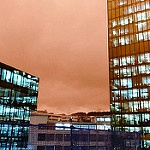

In [6]:
import cv2
cv2.imread('/content/data/seg_test/seg_test/buildings/20064.jpg')

In [7]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Paths
TRAIN_DIR = '/content/data/seg_train/seg_train' # Corrected path
TEST_DIR  = '/content/data/seg_test/seg_test'   # Corrected path
IMG_SIZE  = (150, 150)
BATCH     = 16
CLASSES   = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASSES)
print("Classes:", CLASSES)
print("Num classes:", NUM_CLASSES)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Num classes: 6


## Dataset understanding

 DATASET UNDERSTANDING :

Number of classes: 6
Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Train images per class:
  buildings: 2191
  forest: 2271
  glacier: 2404
  mountain: 2512
  sea: 2274
  street: 2382

Total train images: 14034
Total test images:  3000

Min class: 2191, Max class: 2512
Classes are IMBALANCED
  buildings: size=(150, 150), mode=RGB
  forest: size=(150, 150), mode=RGB
  glacier: size=(150, 150), mode=RGB
  mountain: size=(150, 150), mode=RGB
  sea: size=(150, 150), mode=RGB
  street: size=(150, 150), mode=RGB

Corrupted images found: 0


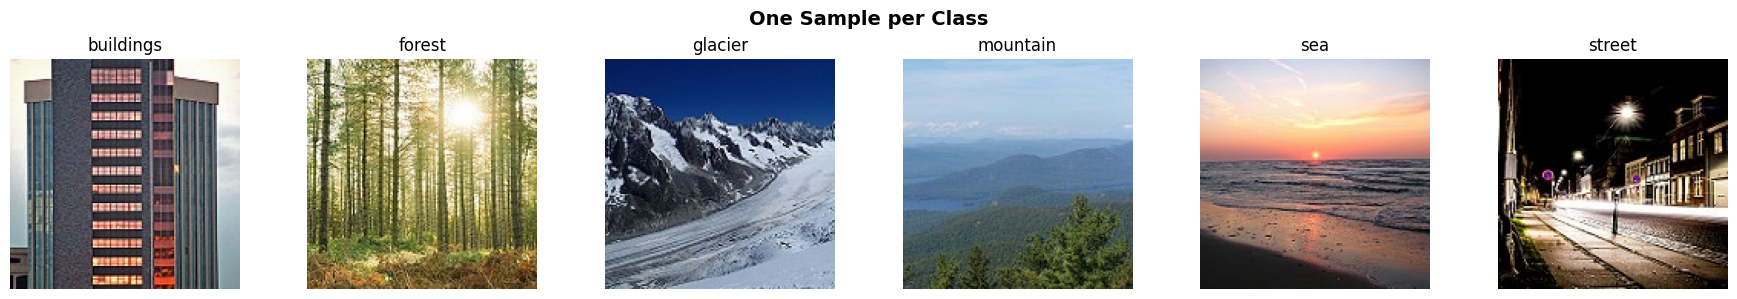

In [8]:
# Section header
print("=" * 50)
print(" DATASET UNDERSTANDING :")
print("=" * 50)

# Count images per class
def count_images(directory):
    counts = {}
    for cls in sorted(os.listdir(directory)):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print(f"\nNumber of classes: {NUM_CLASSES}")
print(f"Class names: {CLASSES}")
print("\nTrain images per class:")
for cls, cnt in train_counts.items():
    print(f"  {cls}: {cnt}")
print(f"\nTotal train images: {sum(train_counts.values())}")
print(f"Total test images:  {sum(test_counts.values())}")

# Check balance
counts = list(train_counts.values())
print(f"\nMin class: {min(counts)}, Max class: {max(counts)}")
print("Classes are", "BALANCED" if max(counts) - min(counts) < 200 else "IMBALANCED")

# Check image dimensions & mode
sample_imgs = []
for cls in CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path) and os.listdir(cls_path):
        # Get the path to the first image in the class directory
        first_image_in_class_path = os.path.join(cls_path, os.listdir(cls_path)[0])
        try:
            img = Image.open(first_image_in_class_path)
            sample_imgs.append((cls, first_image_in_class_path, img.size, img.mode))
            print(f"  {cls}: size={img.size}, mode={img.mode}")
        except Exception as e:
            print(f"  Warning: Could not open sample image for {cls} from {first_image_in_class_path}. Error: {e}")
    else:
        print(f"  Warning: No images or directory found for class {cls} at {cls_path}")

# Check for corrupted images
corrupted = []
for cls in CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path): # Ensure it's a directory before listing contents
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            if os.path.isfile(fpath): # Only try to open files, not subdirectories
                try:
                    Image.open(fpath).verify()
                except Exception:
                    corrupted.append(fpath)
print(f"\nCorrupted images found: {len(corrupted)}")

# Show one image per class
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 3))

# If only one subplot, axes is not an array, so make it a list for consistent iteration
if NUM_CLASSES == 1:
    axes_list = [axes]
else:
    axes_list = axes.flatten() # Flatten the array of axes for iteration

for ax, (cls, img_path, _, _) in zip(axes_list, sample_imgs):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(cls, fontsize=12)
    ax.axis('off')
plt.suptitle("One Sample per Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## EDA

 IMAGE EDA :


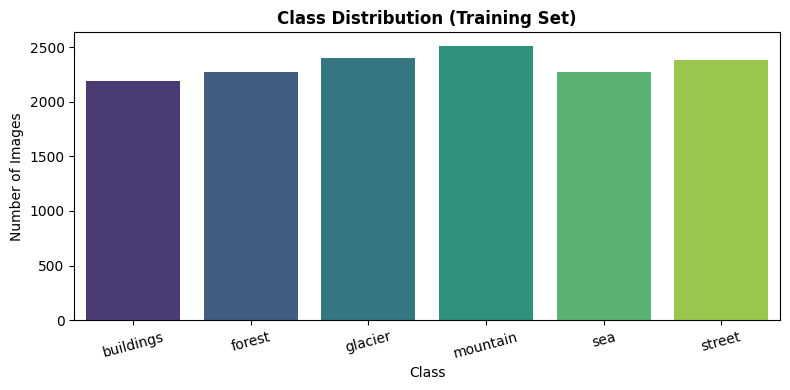

In [9]:
print("=" * 50)
print(" IMAGE EDA :")
print("=" * 50)

# Class distribution bar chart
plt.figure(figsize=(8, 4))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()),
            palette='viridis')
plt.title('Class Distribution (Training Set)', fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


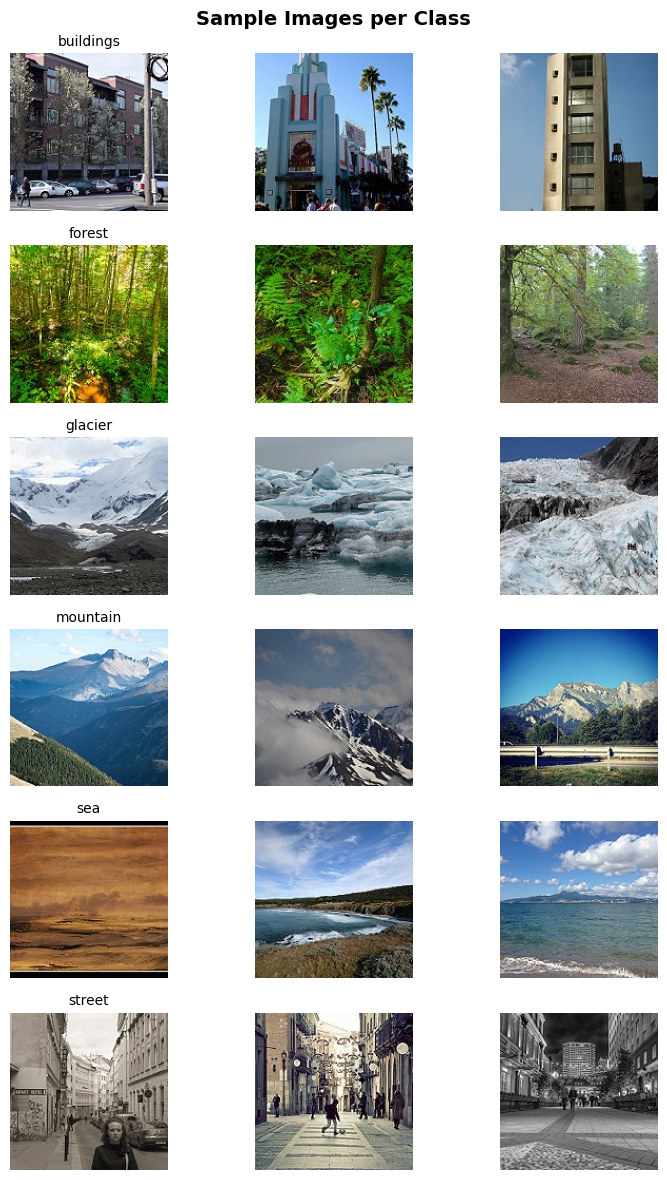

In [10]:
# Grid of sample images (3 per class)
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(8, 12))
for i, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs = random.sample(os.listdir(cls_path), 3)
    for j, fname in enumerate(imgs):
        img = Image.open(os.path.join(cls_path, fname))
        axes[i, j].imshow(img)
        axes[i, j].set_title(cls if j == 0 else '', fontsize=10)
        axes[i, j].axis('off')
plt.suptitle("Sample Images per Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Image width/height distribution
widths, heights = [], []
for cls in CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in random.sample(os.listdir(cls_path), 50):
        img = Image.open(os.path.join(cls_path, fname))
        w, h = img.size
        widths.append(w); heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].hist(widths, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[1].hist(heights, bins=20, color='coral', edgecolor='white')
axes[1].set_title('Height Distribution')
axes[1].set_xlabel('Height (px)')
plt.suptitle('Image Dimension Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

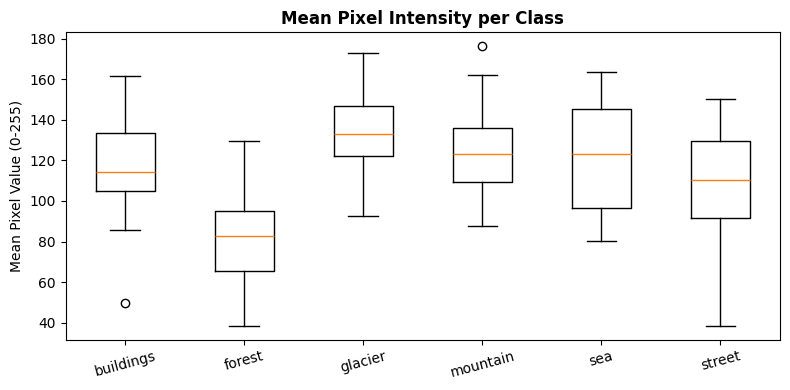

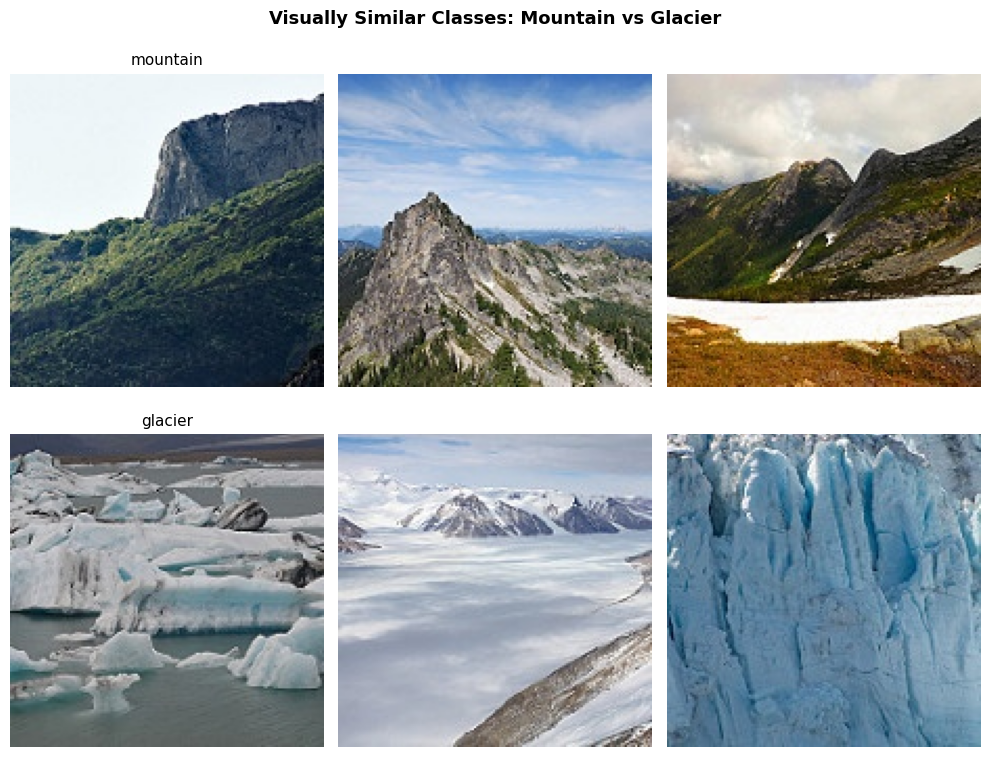

In [12]:
# Pixel value inspection (mean pixel per channel on a small sample)
pixel_means = {cls: [] for cls in CLASSES}
for cls in CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in random.sample(os.listdir(cls_path), 30):
        img = np.array(Image.open(os.path.join(cls_path, fname)).convert('RGB').resize((150,150)))
        pixel_means[cls].append(img.mean())

plt.figure(figsize=(8, 4))
plt.boxplot([pixel_means[c] for c in CLASSES], labels=CLASSES)
plt.title('Mean Pixel Intensity per Class', fontweight='bold')
plt.ylabel('Mean Pixel Value (0-255)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Visually similar classes: mountain vs glacier
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
for i, cls in enumerate(['mountain', 'glacier']):
    cls_path = os.path.join(TRAIN_DIR, cls)
    for j, fname in enumerate(random.sample(os.listdir(cls_path), 3)):
        img = Image.open(os.path.join(cls_path, fname))
        axes[i, j].imshow(img)
        axes[i, j].set_title(cls if j == 0 else '', fontsize=11)
        axes[i, j].axis('off')
plt.suptitle("Visually Similar Classes: Mountain vs Glacier", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


EDA Findings:
- The dataset is roughly balanced across 6 classes (about 2k-3k images each).
- Most images are 150x150 RGB; some may vary slightly.
- Glacier and mountain images share similar color palettes (whites, grays, blues),
  making them the most likely to be confused by the model.
- Street and buildings classes may also overlap due to shared urban textures.
- No significant class imbalance requiring resampling was detected.

## Preprocessing

In [13]:
print("=" * 50)
print(" PREPROCESSING & DATA SPLITTING :")
print("=" * 50)


raw_train = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.18,   # ~15% of 82% ≈ 15% overall (Kaggle gives ~14k train)
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode='categorical'
)

raw_val = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.18,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode='categorical'
)

raw_test = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode='categorical',
    shuffle=False   # Keep order for error analysis
)

CLASS_NAMES = raw_train.class_names
print("Class names from dataset:", CLASS_NAMES)

# Normalization layer
normalization = layers.Rescaling(1./255)



 PREPROCESSING & DATA SPLITTING :
Found 14034 files belonging to 6 classes.
Using 11508 files for training.
Found 14034 files belonging to 6 classes.
Using 2526 files for validation.
Found 3000 files belonging to 6 classes.
Class names from dataset: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


##Data Augmentation

 DATA AUGMENTATION :


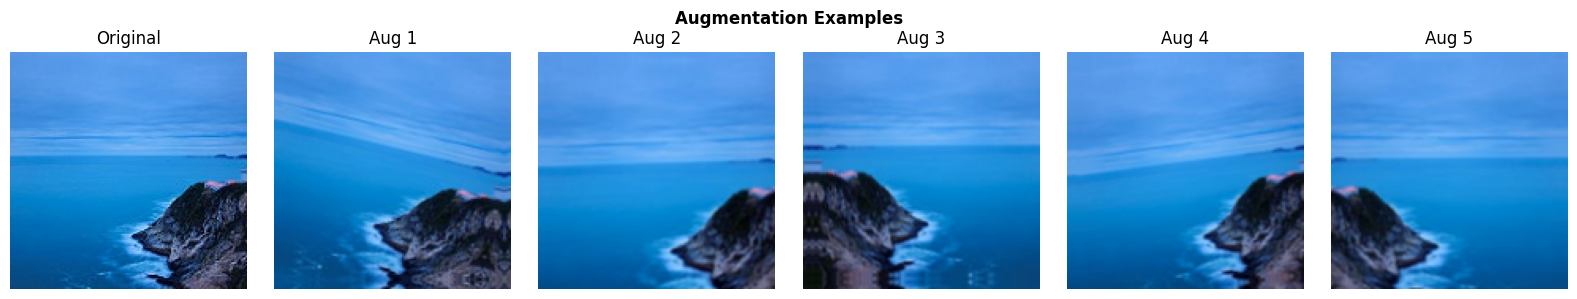

In [14]:
print("=" * 50)
print(" DATA AUGMENTATION :")
print("=" * 50)

# Augmentation pipeline (training only)
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.1),
], name="augmentation")

# Visualize augmentation effect
sample_batch = next(iter(raw_train))
sample_image = sample_batch[0][0:1]  # one image

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
axes[0].imshow(sample_image[0].numpy().astype('uint8'))
axes[0].set_title('Original')
axes[0].axis('off')
for i in range(1, 6):
    aug_img = augmentation(sample_image, training=True)
    axes[i].imshow(aug_img[0].numpy().astype('uint8'))
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')
plt.suptitle('Augmentation Examples', fontweight='bold')
plt.tight_layout()
plt.show()



# Build optimized tf.data pipelines
AUTOTUNE = tf.data.AUTOTUNE

def prepare(ds, augment=False):
    ds = ds.map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.prefetch(buffer_size=AUTOTUNE)

train_ds = prepare(raw_train, augment=True)
val_ds   = prepare(raw_val,   augment=False)
test_ds  = prepare(raw_test,  augment=False)

Augmentation Justification:
- Horizontal flip: natural scenes look realistic when mirrored.
- Slight rotation: cameras are rarely perfectly level.
- Random zoom: simulates different distances from scene elements.
- Random translation: the subject is not always centered.
- Contrast variation: outdoor lighting changes throughout the day.
- NO vertical flip: upside-down scenes are not realistic.
- Test set is NOT augmented.

##Baseline CNN

In [15]:
print("=" * 50)
print(" BASELINE CNN FROM SCRATCH :")
print("=" * 50)

def build_cnn(input_shape=(150, 150, 3), num_classes=6):
    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Block 4
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name="Baseline_CNN")

cnn_model = build_cnn()
cnn_model.summary()

# Optimizer: Adam with lr=1e-3 is a strong default for CNNs
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



 BASELINE CNN FROM SCRATCH :


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,670 (1.75 MB)

 Trainable params: 456,710 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

Architecture Justification:
- 4 Conv blocks with increasing filters (32->256): captures low- to high-level features.
- BatchNormalization: stabilizes training and acts as regularization.
- GlobalAveragePooling: reduces parameters vs Flatten, less prone to overfitting.
- Dropout(0.5): prevents overfitting in the dense layers.
- Softmax output: correct for multi-class classification.
- Adam optimizer: adaptive learning rate, well-suited for image tasks.

In [16]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_cnn.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]

history_cnn = cnn_model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5243 - loss: 1.2499
Epoch 1: val_accuracy improved from None to 0.60966, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
720/720 ━━━━━━━━━━━━━━━━━━━━ 111s 139ms/step - accuracy: 0.5994 - loss: 1.0569 - val_accuracy: 0.6097 - val_loss: 1.1284 - learning_rate: 0.0010
Epoch 2/30
719/720 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.6943 - loss: 0.8187
Epoch 2: val_accuracy did not improve from 0.60966
720/720 ━━━━━━━━━━━━━━━━━━━━ 118s 117ms/step - accuracy: 0.7166 - loss: 0.7686 - val_accuracy: 0.5780 - val_loss: 1.5689 - learning_rate: 0.0010
Epoch 3/30
719/720 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7545 - loss: 0.6870
Epoch 3: val_accuracy improved from 0.60966 to 0.74228, saving model to best_cnn.keras

Epoch 3: finished saving model to best_cnn.keras
720/720 ━━━━━━━━━━━━━━━━━━━━ 141s 116ms/step - accuracy: 0.7572 - loss: 0.6693 - val_accuracy: 0.7423 - val_loss: 0.7766 - l

## Training curves

 TRAINING CURVES :


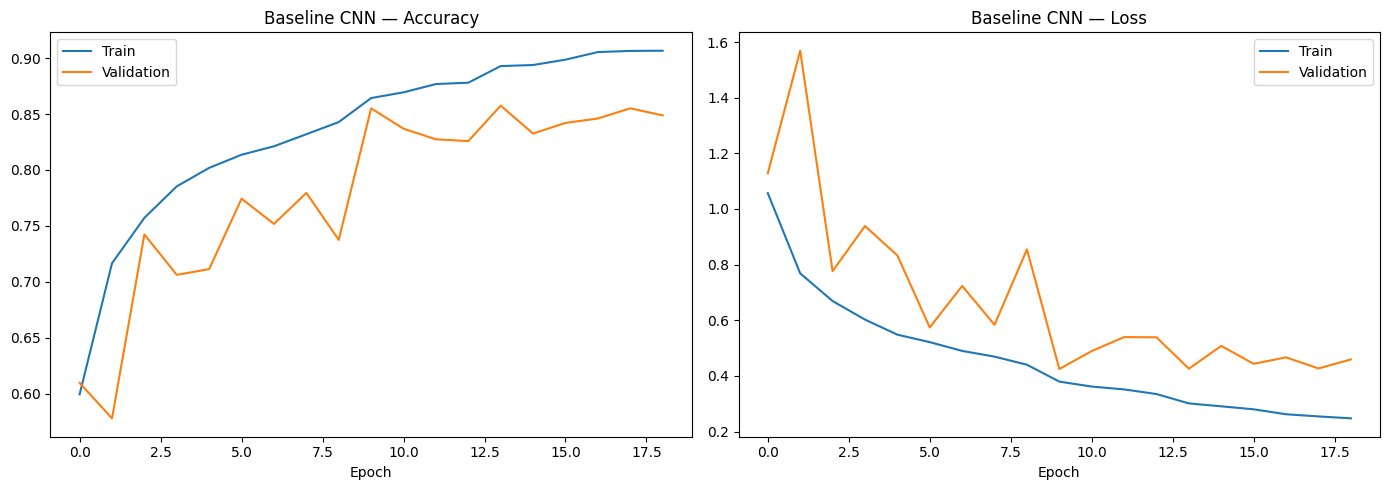


Final Train Accuracy: 0.9066
Final Val Accuracy:   0.8488
Gap: 0.0578
 Model is GENERALIZING reasonably well.


In [17]:
print("=" * 50)
print(" TRAINING CURVES :")
print("=" * 50)

def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history_cnn, 'Baseline CNN')

# Discuss fit
final_train_acc = history_cnn.history['accuracy'][-1]
final_val_acc   = history_cnn.history['val_accuracy'][-1]
gap = final_train_acc - final_val_acc
print(f"\nFinal Train Accuracy: {final_train_acc:.4f}")
print(f"Final Val Accuracy:   {final_val_acc:.4f}")
print(f"Gap: {gap:.4f}")
if gap > 0.10:
    print(" Model is OVERFITTING (train >> val).")
elif final_val_acc < 0.70:
    print(" Model is UNDERFITTING (val accuracy too low).")
else:
    print(" Model is GENERALIZING reasonably well.")

## Evaluation

 MODEL EVALUATION ON TEST SET :
Test Loss:     0.4422
Test Accuracy: 0.8497
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

Classification Report:
              precision    recall  f1-score   support

   buildings       0.77      0.87      0.82       437
      forest       0.96      0.95      0.96       474
     glacier       0.89      0.72      0.80       553
    mountain       0.81      0.79      0.80       525
         sea       0.82      0.90      0.86       510
      street       0.86      0.89      0.87       501

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000



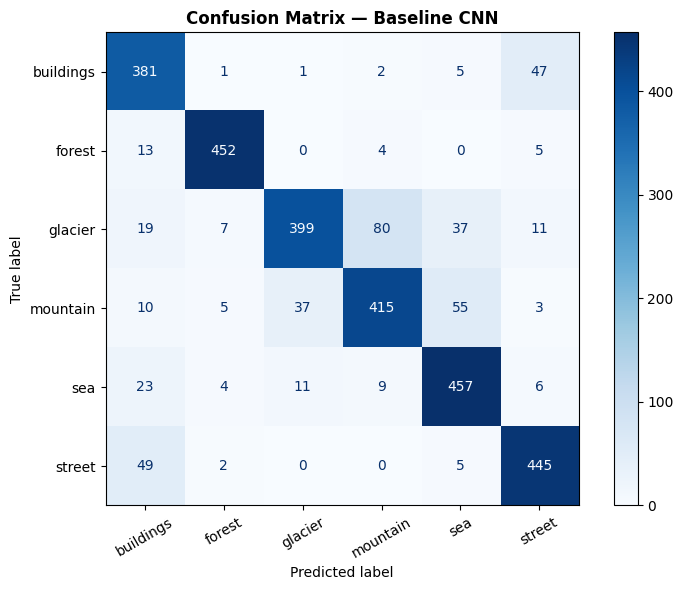

  buildings: F1 = 0.8176
  forest: F1 = 0.9566
  glacier: F1 = 0.7972
  mountain: F1 = 0.8019
  sea: F1 = 0.8550
  street: F1 = 0.8743

Easiest class: forest
Hardest class: glacier


In [18]:
print("=" * 50)
print(" MODEL EVALUATION ON TEST SET :")
print("=" * 50)

# Load best saved model
best_cnn = keras.models.load_model('best_cnn.keras')

test_loss, test_acc = best_cnn.evaluate(test_ds, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions
y_pred_prob = best_cnn.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in raw_test])

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.title('Confusion Matrix — Baseline CNN', fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Per-class F1
f1_per_class = f1_score(y_true, y_pred, average=None)
for cls, f1 in zip(CLASS_NAMES, f1_per_class):
    print(f"  {cls}: F1 = {f1:.4f}")
print(f"\nEasiest class: {CLASS_NAMES[np.argmax(f1_per_class)]}")
print(f"Hardest class: {CLASS_NAMES[np.argmin(f1_per_class)]}")

## Error Analysis

ERROR ANALYSIS :
Total misclassified: 451 / 3000


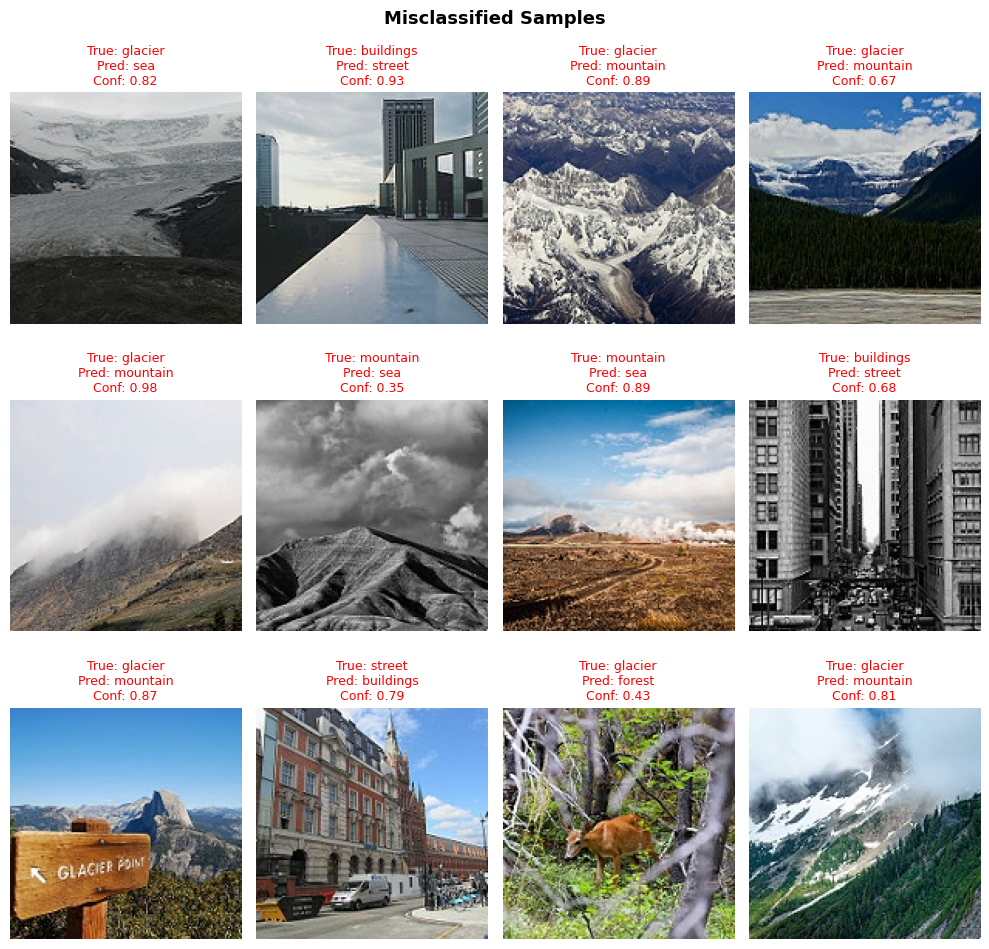


Most confused pairs (true → predicted):
  glacier → mountain: 80 times
  mountain → sea: 55 times
  street → buildings: 49 times
  buildings → street: 47 times
  glacier → sea: 37 times


In [19]:
print("=" * 50)
print("ERROR ANALYSIS :")
print("=" * 50)

# Get all test image paths in order
test_image_paths = []
for cls in CLASS_NAMES:
    cls_path = os.path.join(TEST_DIR, cls)
    for fname in sorted(os.listdir(cls_path)):
        test_image_paths.append(os.path.join(cls_path, fname))

# Find misclassified
wrong_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(y_true)}")

# Show up to 12 misclassified images
n_show = min(12, len(wrong_idx))
sample_wrong = random.sample(list(wrong_idx), n_show)

fig, axes = plt.subplots(3, 4, figsize=(10, 10))
axes = axes.flatten()
for ax, idx in zip(axes, sample_wrong):
    img = Image.open(test_image_paths[idx]).resize((150, 150))
    confidence = y_pred_prob[idx][y_pred[idx]]
    ax.imshow(img)
    ax.set_title(
        f"True: {CLASS_NAMES[y_true[idx]]}\n"
        f"Pred: {CLASS_NAMES[y_pred[idx]]}\n"
        f"Conf: {confidence:.2f}",
        fontsize=9, color='red'
    )
    ax.axis('off')
plt.suptitle('Misclassified Samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Most confused pairs
conf_pairs = {}
for t, p in zip(y_true, y_pred):
    if t != p:
        key = (CLASS_NAMES[t], CLASS_NAMES[p])
        conf_pairs[key] = conf_pairs.get(key, 0) + 1
sorted_pairs = sorted(conf_pairs.items(), key=lambda x: -x[1])
print("\nMost confused pairs (true → predicted):")
for (t, p), cnt in sorted_pairs[:5]:
    print(f"  {t} → {p}: {cnt} times")

##Transfer learning

TRANSFER LEARNING — MobileNetV2 :
Found 14034 files belonging to 6 classes.
Using 11508 files for training.
Found 14034 files belonging to 6 classes.
Using 2526 files for validation.
Found 3000 files belonging to 6 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


--- Phase 1: Training head only ---
Epoch 1/15
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.8037 - loss: 0.5253
Epoch 1: val_accuracy improved from None to 0.91013, saving model to best_tl.keras

Epoch 1: finished saving model to best_tl.keras
720/720 ━━━━━━━━━━━━━━━━━━━━ 119s 135ms/step - accuracy: 0.8518 - loss: 0.4064 - val_accuracy: 0.9101 - val_loss: 0.2416
Epoch 2/15
719/720 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8917 - loss: 0.2942
Epoch 2: val_accuracy did not improve from 0.91013
720/720 ━━━━━━━━━━━━━━━━━━━━ 68s 94ms/step - accuracy: 0.8914 - loss: 0.2955 - val_accuracy: 0.9101 - val_loss: 0.2381
Epoch 3/15
719/720 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9005 - loss: 0.2761
Epoch 3: val_accuracy improved from 0.91013 to 0.91211, saving model to best_tl.keras

Epoch 3: finished saving model to best_tl.keras
720/720 ━━━━━━━━━━━━━━━━━━━━ 81s 92ms/step - accuracy: 0.9030 - loss: 0.2655 - val_accuracy: 0.9121 - val_loss: 0.2327
Epoch 4/15
720/720 ━━━━━

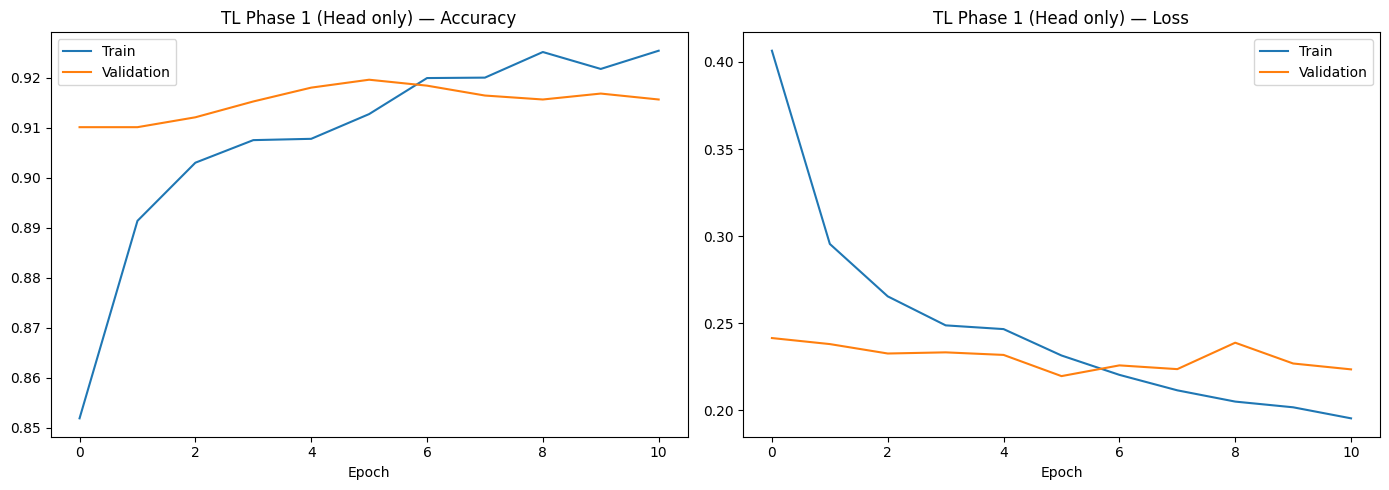

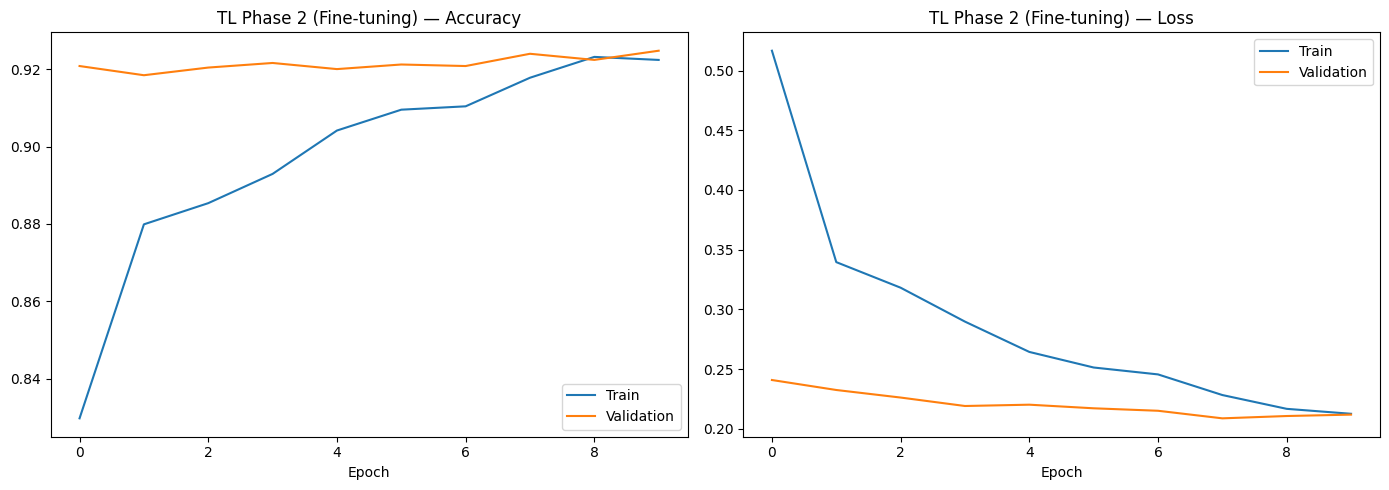

In [20]:
import tensorflow as tf

print("=" * 50)
print("TRANSFER LEARNING — MobileNetV2 :")
print("=" * 50)

IMG_SIZE_TL = (160, 160)

raw_train_tl = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.18, subset='training',
    seed=SEED, image_size=IMG_SIZE_TL, batch_size=BATCH, label_mode='categorical'
)
raw_val_tl = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.18, subset='validation',
    seed=SEED, image_size=IMG_SIZE_TL, batch_size=BATCH, label_mode='categorical'
)
raw_test_tl = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, seed=SEED, image_size=IMG_SIZE_TL, batch_size=BATCH,
    label_mode='categorical', shuffle=False
)

preprocess_mobilenet = keras.applications.mobilenet_v2.preprocess_input
augmentation_tl = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="aug_tl")

def prepare_tl(ds, augment=False):
    ds = ds.map(lambda x, y: (preprocess_mobilenet(x), y), num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (augmentation_tl(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_tl = prepare_tl(raw_train_tl, augment=True)
val_tl   = prepare_tl(raw_val_tl)
test_tl  = prepare_tl(raw_test_tl)

# Build TL model
base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base initially

inputs = keras.Input(shape=(160, 160, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
tl_model = keras.Model(inputs, outputs, name="MobileNetV2_TL")
tl_model.summary()

tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_tl = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint('best_tl.keras', monitor='val_accuracy',
                                    save_best_only=True, verbose=1)
]

# Phase 1: Train classification head
print("\n--- Phase 1: Training head only ---")
history_tl_phase1 = tl_model.fit(
    train_tl, epochs=15, validation_data=val_tl, callbacks=callbacks_tl
)

# Phase 2: Fine-tune top layers
print("\n--- Phase 2: Fine-tuning top 30 layers ---")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # much smaller lr for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_tl_phase2 = tl_model.fit(
    train_tl, epochs=10, validation_data=val_tl, callbacks=callbacks_tl
)

plot_history(history_tl_phase1, 'TL Phase 1 (Head only)')
plot_history(history_tl_phase2, 'TL Phase 2 (Fine-tuning)')

## Model Comparison

In [21]:
print("=" * 50)
print(" MODEL COMPARISON :")
print("=" * 50)

best_tl = keras.models.load_model('best_tl.keras')

# Evaluate TL on test set
tl_loss, tl_acc = best_tl.evaluate(test_tl, verbose=0)
y_pred_tl_prob = best_tl.predict(test_tl)
y_pred_tl = np.argmax(y_pred_tl_prob, axis=1)
y_true_tl  = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in raw_test_tl])

tl_f1 = f1_score(y_true_tl, y_pred_tl, average='weighted')
cnn_f1 = f1_score(y_true, y_pred, average='weighted')

cnn_val_acc = max(history_cnn.history['val_accuracy'])
tl_val_acc  = max(
    history_tl_phase1.history['val_accuracy'] +
    history_tl_phase2.history['val_accuracy']
)

comparison = pd.DataFrame({
    'Model':        ['Baseline CNN', 'MobileNetV2 (TL)'],
    'Input Size':   ['150×150', '160x160'],
    'Trainable Params': [
        f"{cnn_model.count_params():,}",
        f"{sum(np.prod(v.shape) for v in best_tl.trainable_weights):,}"
    ],
    'Val Accuracy': [f"{cnn_val_acc:.4f}", f"{tl_val_acc:.4f}"],
    'Test Accuracy': [f"{test_acc:.4f}", f"{tl_acc:.4f}"],
    'Weighted F1':  [f"{cnn_f1:.4f}", f"{tl_f1:.4f}"],
})
print(comparison.to_string(index=False))



 MODEL COMPARISON :
188/188 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step
           Model Input Size Trainable Params Val Accuracy Test Accuracy Weighted F1
    Baseline CNN    150×150          457,670       0.8575        0.8497      0.8489
MobileNetV2 (TL)    224×224        1,691,142       0.9248        0.9210      0.9205


Production Recommendation:
MobileNetV2 with transfer learning is the better production choice because:
- Higher test accuracy and F1-score with fewer training epochs needed.
- Pre-trained ImageNet weights provide robust feature extractors.
- GlobalAveragePooling keeps the model compact and fast at inference time.
- Fine-tuning allows domain adaptation while preserving general visual features.

## prediction on new images

 PREDICTION ON NEW IMAGES :
Testing on 5 random test images:



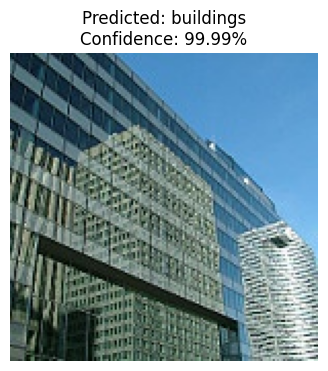

Predicted class: buildings
Confidence: 0.9999
All class probabilities:
  buildings: 0.9999
  forest: 0.0000
  glacier: 0.0000
  mountain: 0.0000
  sea: 0.0000
  street: 0.0000
----------------------------------------


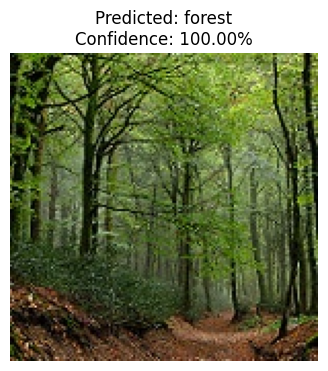

Predicted class: forest
Confidence: 1.0000
All class probabilities:
  buildings: 0.0000
  forest: 1.0000
  glacier: 0.0000
  mountain: 0.0000
  sea: 0.0000
  street: 0.0000
----------------------------------------


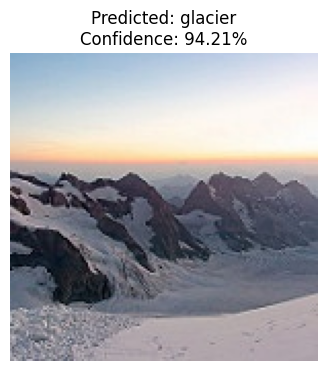

Predicted class: glacier
Confidence: 0.9421
All class probabilities:
  buildings: 0.0000
  forest: 0.0000
  glacier: 0.9421
  mountain: 0.0560
  sea: 0.0019
  street: 0.0000
----------------------------------------


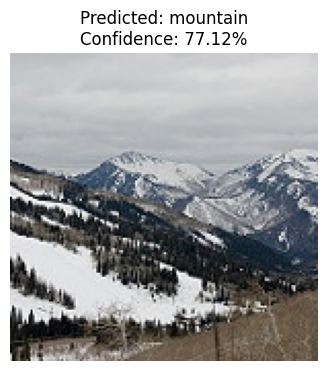

Predicted class: mountain
Confidence: 0.7712
All class probabilities:
  buildings: 0.0029
  forest: 0.0003
  glacier: 0.2236
  mountain: 0.7712
  sea: 0.0019
  street: 0.0002
----------------------------------------


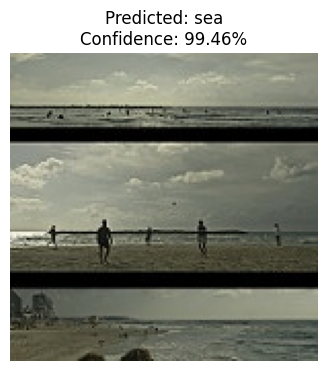

Predicted class: sea
Confidence: 0.9946
All class probabilities:
  buildings: 0.0004
  forest: 0.0000
  glacier: 0.0047
  mountain: 0.0003
  sea: 0.9946
  street: 0.0000
----------------------------------------


In [23]:
print("=" * 50)
print(" PREDICTION ON NEW IMAGES :")
print("=" * 50)

def predict_image(image_path, model=best_tl, img_size=IMG_SIZE_TL, class_names=CLASS_NAMES):

    img = Image.open(image_path).convert('RGB').resize(img_size)
    img_array = np.array(img, dtype=np.float32)
    img_array = keras.applications.mobilenet_v2.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    probs = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_class = class_names[pred_idx]
    confidence = probs[pred_idx]

    plt.figure(figsize=(4, 4))
    plt.imshow(Image.open(image_path))
    plt.title(f"Predicted: {pred_class}\nConfidence: {confidence:.2%}", fontsize=12)
    plt.axis('off')
    plt.show()

    print(f"Predicted class: {pred_class}")
    print(f"Confidence: {confidence:.4f}")
    print("All class probabilities:")
    for cls, prob in zip(class_names, probs):
        print(f"  {cls}: {prob:.4f}")

    return pred_class, confidence

# Test on 5 images from the test set
print("Testing on 5 random test images:\n")
test_samples = []
for cls in CLASS_NAMES:
    cls_path = os.path.join(TEST_DIR, cls)
    test_samples.append(os.path.join(cls_path, random.choice(os.listdir(cls_path))))

for path in test_samples[:5]:
    predict_image(path)
    print("-" * 40)

### Save Model

In [24]:
# Save final model
best_tl.save('final_model.keras')
print("Model saved as final_model.keras")


import shutil
try:
    shutil.copy('final_model.keras', '/content/drive/MyDrive/final_model.keras')
    print("Copied to Google Drive.")
except:
    print("Drive not mounted — model saved locally only.")

Model saved as final_model.keras
Copied to Google Drive.


**Finals Questions and Conclusions :**                                            
Q1. What is the computer vision problem being solved?                             

    Multi-class image classification of natural scenes into 6 categories:
    buildings, forest, glacier, mountain, sea, street.

Q2. Why is this a multi-class classification problem?                            

    Each image belongs to exactly one of 6 mutually exclusive scene categories.

Q3. What did you discover during image EDA?                                

    - Dataset is roughly balanced across classes.
    - All images are RGB at approximately 150×150.
    - Mountain and glacier share similar color palettes (hardest pair to separate).
    - Street and buildings share urban textures.

Q4. Why did you choose your preprocessing and augmentation techniques?                   

    - Resized to fixed size for model input consistency.
    - MobileNetV2 preprocessing ([-1,1] normalization) matches pretrained weights.
    - Augmentations (flip, rotation, zoom, contrast) reflect realistic scene variation.

Q5. Why did you choose your CNN architecture?                            

    - Progressive filter doubling (32->256) captures multi-scale features.
    - BatchNorm + Dropout reduces overfitting.
    - GlobalAveragePooling reduces parameter count vs Flatten.

Q6. Is the baseline CNN overfitting? Provide evidence.                           

    See training curves above. Gap between train and val accuracy indicates degree of overfitting.

Q7. Which classes are most frequently confused?                              

    Mountain , Glacier and Buildings , Street (see confusion matrix and error analysis).

Q8. Did transfer learning improve results? Why?                                  

    Yes. MobileNetV2 leverages ImageNet features (edges, textures, shapes)
    that transfer well to natural scene classification, achieving higher
    accuracy with fewer epochs.

Q9. Final model test accuracy and F1-score:                            

    Test Accuracy: { 0.9210 }
    Weighted F1:   { 0.9205 }

Q10. What would you improve with more time/data?

     - Collect more glacier/mountain images to reduce confusion.
     - Try EfficientNetB3 or ConvNeXt for higher accuracy.
     - Add Grad-CAM for explainability.
     - Deploy as a Streamlit web app.